Used Car Price Prediction: Karachi Market

Stage 0: Problem Framing

Questions to ask myself before any code:

- What exactly am I predicting? (name the column)
- Regression or classification, and why?
- Who/what would use this, and how would a wrong prediction hurt?
- What does "good" look like here, which metric, and why that one?
- What's the scope of this data? What should this model NOT be trusted to generalize to?

Stage 0: Problem Framing, Answers

- Target: Predicting `listingPrice` for used cars.
- Problem type: Regression.
- Audience / cost of being wrong: A prospective buyer deciding whether an asking price is fair. A wrong prediction could cost them financially, overpaying for a car that's actually overpriced for its specs.
- Metric: RMSE, reported alongside MAE. RMSE is in the same units as price (PKR) and penalizes large misses more heavily, but that outlier-sensitivity only makes sense once Stage 2 cleaning is done, otherwise a single bad listing can distort it.
- Scope, what this model should NOT be trusted for:
  - Other cities. Every row in this dataset is a Karachi listing (confirmed via the `name` field), the model has seen zero data from Lahore, Islamabad, or anywhere else, and different cities/provinces can have different registration/tax regimes and demand patterns. No evidence exists either way for those markets.
  - Long time horizons. This is a snapshot of Karachi asking prices as of ~December 2025 (per the filename). Used car prices move with currency devaluation, fuel prices, and import policy, so this model's accuracy should be expected to decay without retraining on fresher data.
  - Actual sale price. `listingPrice` is the seller's asking price, not a confirmed transaction price. In a market where haggling is normal, the model is really predicting "what a seller would list this car for," not "what it will sell for."


Stage 1: Data Loading & Structural Inspection

First instinct: check the data is mechanically sound. Don't analyze meaning yet.

In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv('used_car_listings_13_12_2025.csv')

In [3]:
df.head()

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant,age
0,2013.0,Toyota,Hybrid,Toyota Prius 2013 for sale in Karachi,Automatic,1800cc,"156,000 km",4125000.0,Prius,12.0
1,2008.0,Toyota,Petrol,Toyota Vitz 2008 for sale in Karachi,Automatic,1000cc,"85,000 km",2080000.0,Vitz,17.0
2,2022.0,Daihatsu,Petrol,Daihatsu Mira 2022 for sale in Karachi,Automatic,660cc,"16,000 km",3575000.0,Mira,3.0
3,2022.0,Toyota,Petrol,Toyota Passo 2022 for sale in Karachi,Automatic,1000cc,"68,000 km",3990000.0,Passo,3.0
4,2013.0,Honda,Hybrid,Honda Insight 2013 for sale in Karachi,Automatic,1300cc,"78,000 km",2890000.0,Insight,12.0


In [4]:
df.describe()

,year,listingPrice,age
count,15171.000000,1.517100e+04,15171.000000
mean,2014.120823,5.271934e+06,10.879177
std,8.798385,8.277969e+06,8.798385
min,1951.000000,1.040000e+05,0.000000
25%,2009.000000,1.600000e+06,4.000000
50%,2017.000000,3.200000e+06,8.000000
75%,2021.000000,5.650000e+06,16.000000
max,2025.000000,1.450000e+08,74.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          15171 non-null  float64
 1   manufacturer  15171 non-null  str    
 2   fuelType      15171 non-null  str    
 3   name          15171 non-null  str    
 4   transmission  15171 non-null  str    
 5   engine        15171 non-null  str    
 6   mileage       15171 non-null  str    
 7   listingPrice  15171 non-null  float64
 8   variant       15171 non-null  str    
 9   age           15171 non-null  float64
dtypes: float64(3), str(7)
memory usage: 1.2 MB


Duplicates: exact
Every column identical. Found via `df.duplicated()`.

In [6]:
df.duplicated().sum()

np.int64(2477)

In [13]:
df[df.duplicated(keep=False)].sort_values(by=['manufacturer','variant','year','mileage']).head(20)

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant,age
1935,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
2017,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
4840,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
4958,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
3843,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
3901,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
4630,2012.0,Audi,Petrol,Audi A4 2012 for sale in Karachi,Automatic,1800cc,"39,785 km",7500000.0,A4,13.0
4641,2012.0,Audi,Petrol,Audi A4 2012 for sale in Karachi,Automatic,1800cc,"39,785 km",7500000.0,A4,13.0
263,2014.0,Audi,Petrol,Audi A4 2014 for sale in Karachi,Automatic,1800cc,"48,000 km",6500000.0,A4,11.0
312,2014.0,Audi,Petrol,Audi A4 2014 for sale in Karachi,Automatic,1800cc,"48,000 km",6500000.0,A4,11.0


Duplicates: near
Same manufacturer/variant/year/engine/fuelType/transmission, but mileage/price may differ, could be the same car re-listed, or just a popular config shared by different cars.

In [7]:
df[df.duplicated(subset=['manufacturer','variant','year','engine','fuelType','transmission'], keep=False)].sort_values(by=['manufacturer','variant','year','engine','fuelType','transmission']).head(20)

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant,age
2175,2016.0,Audi,Petrol,Audi A3 2016 for sale in Karachi,Automatic,1200cc,"101,000 km",5950000.0,A3,9.0
2302,2016.0,Audi,Petrol,Audi A3 2016 for sale in Karachi,Automatic,1200cc,"41,000 km",6700000.0,A3,9.0
9914,2016.0,Audi,Petrol,Audi A3 2016 for sale in Karachi,Automatic,1200cc,"62,000 km",5850000.0,A3,9.0
1935,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
2017,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
4840,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
4958,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
3843,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
3901,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
4630,2012.0,Audi,Petrol,Audi A4 2012 for sale in Karachi,Automatic,1800cc,"39,785 km",7500000.0,A4,13.0


Stage 2: Data Cleaning

Fix what's structurally broken. No new features yet, no analysis conclusions yet, just correctness.

In [8]:
df_clean = df.drop_duplicates(keep='first')

In [9]:
df_clean.shape

(12694, 10)

In [10]:
df_clean['mileage'] = df_clean['mileage'].str.replace(',', '').str.replace(' km', '').astype(int)

df_clean['engine'] = df_clean['engine'].str.replace('cc', '')
df_clean.loc[df_clean['engine'] == '', 'engine'] = '0'
df_clean['engine'] = df_clean['engine'].astype(int)

Investigating mileage spread within near-duplicate groups
Still just inspecting, no decision applied yet. `count` alone doesn't mean duplicate (a popular new model naturally has many genuinely different, low-mileage listings); `range` tells you how spread out a group's mileage is.

In [11]:
df_clean.groupby(['manufacturer', 'variant', 'year', 'engine', 'fuelType', 'transmission'])['mileage'].agg(['count', 'min', 'max'])

count     min  \
manufacturer variant year   engine fuelType transmission                  
Adam         Revo    2006.0 800    Petrol   Manual            1   50000   
Audi         A3      2015.0 1200   Petrol   Automatic         1   80000   
                     2016.0 1200   Petrol   Automatic         3   41000   
                     2018.0 1200   Petrol   Automatic         2   45812   
                     2019.0 1200   Petrol   Automatic         1   43359   
...                                                         ...     ...   
Volkswagen   Beetle  1971.0 1300   Petrol   Manual            1   97823   
                            1600   Petrol   Manual            1  120000   
                     1974.0 1200   Petrol   Manual            1     250   
             Up      2012.0 1000   Petrol   Automatic         1   78000   
Willys       M38     1952.0 3300   Diesel   Manual            1   30000   

                                                             max  
manufacturer variant year   engine fuelType transmission          
Adam         Revo    2006.0 800    Petrol   Manual         50000  
Audi         A3      2015.0 1200   Petrol   Automatic      80000  
                     2016.0 1200   Petrol   Automatic     101000  
                     2018.0 1200   Petrol   Automatic      92000  
                     2019.0 1200   Petrol   Automatic      43359  
...                                                          ...  
Volkswagen   Beetle  1971.0 1300   Petrol   Manual         97823  
                            1600   Petrol   Manual        120000  
                     1974.0 1200   Petrol   Manual           250  
             Up      2012.0 1000   Petrol   Automatic      78000  
Willys       M38     1952.0 3300   Diesel   Manual         30000  

[2598 rows x 3 columns]

In [13]:
summary = df_clean.groupby(['manufacturer', 'variant', 'year', 'engine', 'fuelType', 'transmission'])['mileage'].agg(['count', 'min', 'max'])
summary['range'] = summary['max'] - summary['min']
summary['range']

manufacturer  variant  year    engine  fuelType  transmission
Adam          Revo     2006.0  800     Petrol    Manual              0
Audi          A3       2015.0  1200    Petrol    Automatic           0
                       2016.0  1200    Petrol    Automatic       60000
                       2018.0  1200    Petrol    Automatic       46188
                       2019.0  1200    Petrol    Automatic           0
                                                                 ...  
Volkswagen    Beetle   1971.0  1300    Petrol    Manual              0
                               1600    Petrol    Manual              0
                       1974.0  1200    Petrol    Manual              0
              Up       2012.0  1000    Petrol    Automatic           0
Willys        M38      1952.0  3300    Diesel    Manual              0
Name: range, Length: 2598, dtype: int64

In [14]:
multi = summary[summary['count'] > 1]
multi

count    min  \
manufacturer variant     year   engine fuelType transmission                 
Audi         A3          2016.0 1200   Petrol   Automatic         3  41000   
                         2018.0 1200   Petrol   Automatic         2  45812   
             A4          2014.0 1800   Petrol   Automatic         3  48000   
                         2016.0 1400   Petrol   Automatic         2  48000   
                         2017.0 1400   Petrol   Automatic         2  72000   
...                                                             ...    ...   
Toyota       Yaris Sedan 2024.0 1300   Petrol   Automatic         8   1700   
                                1500   Petrol   Automatic         2   7800   
                         2025.0 1300   Petrol   Automatic        28      5   
                                                Manual            3     69   
United       Bravo       2021.0 800    Petrol   Manual            2  30000   

                                                                 max  range  
manufacturer variant     year   engine fuelType transmission                 
Audi         A3          2016.0 1200   Petrol   Automatic     101000  60000  
                         2018.0 1200   Petrol   Automatic      92000  46188  
             A4          2014.0 1800   Petrol   Automatic      52155   4155  
                         2016.0 1400   Petrol   Automatic      62500  14500  
                         2017.0 1400   Petrol   Automatic      81000   9000  
...                                                              ...    ...  
Toyota       Yaris Sedan 2024.0 1300   Petrol   Automatic      27000  25300  
                                1500   Petrol   Automatic      24342  16542  
                         2025.0 1300   Petrol   Automatic      10000   9995  
                                                Manual          5100   5031  
United       Bravo       2021.0 800    Petrol   Manual         74000  44000  

[1330 rows x 4 columns]

Decision: final near-duplicate rule

Group-level `range` has a blind spot for groups of 3+ (a tight real pair can hide inside a wider, mostly-legitimate group, see the Audi A4 2014 case in `project/notes/NOTES.md`). Rather than chase that further, the rule used here: treat rows as the same car only if they match on every spec and `listingPrice` exactly. Known limitation (documented, not solved): this doesn't separately verify mileage closeness, so it could rarely over- or under-merge (e.g. two identically-priced new cars from the same dealer).

In [15]:
df_final = df_clean.drop_duplicates(
    subset=['manufacturer','variant','year','engine','fuelType','transmission','listingPrice'],
    keep='last'
)
df_final.shape

(10250, 10)

`age` vs `year`: dropping the redundant one

`age` is a fixed transform of `year` (found via `.describe()`, identical standard deviations to six decimals). Keeping both would feed the model the same information twice (multicollinearity). Keeping `year`, dropping `age`.

In [16]:
df_final = df_final.drop(columns=['age'])
df_final.info()

<class 'pandas.DataFrame'>
Index: 10250 entries, 0 to 15170
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          10250 non-null  float64
 1   manufacturer  10250 non-null  str    
 2   fuelType      10250 non-null  str    
 3   name          10250 non-null  str    
 4   transmission  10250 non-null  str    
 5   engine        10250 non-null  int64  
 6   mileage       10250 non-null  int64  
 7   listingPrice  10250 non-null  float64
 8   variant       10250 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 800.8 KB


Removing invalid mileage values found during Stage 3 EDA

While plotting mileage's distribution below (Stage 3), sorting by mileage turned up two separate problems: thirteen rows sharing the exact placeholder value 1,000,000 km, plus a handful of near-identical values (999999, 999998, 999990, 999000) that are almost certainly the same placeholder with slightly different rounding. Beyond that cluster, some remaining rows have mileage that is far too high for the car's age, for example a 2018 Suzuki Swift showing 980,000 km, about 140,000 km per year, which is not physically plausible. Full reasoning and the rows that led here are in `project/notes/NOTES.md`.

In [17]:
# Remove the placeholder cluster sitting right at the ceiling (1,000,000 and near-identical values)
df_final = df_final[df_final['mileage'] < 999000]

# Remove remaining rows where mileage is implausible for the car's age
reference_year = 2025
age_years = (reference_year - df_final['year']).clip(lower=1)
implied_km_per_year = df_final['mileage'] / age_years

df_final = df_final[implied_km_per_year <= 50000]
df_final.shape

(10173, 9)

Removing invalid engine values found during Stage 3 EDA

Sorting by engine size (below, Stage 3) surfaced a placeholder cluster (three unrelated cars, a Suzuki Vitara, a Honda Civic, and a Toyota Land Cruiser, all sharing the identical, impossible `15000`), plus several individual values too large for what the car actually is (a Daihatsu Move, a kei car legally capped at 660cc, showing `6600`, likely a stray extra zero; a Toyota IST, Mitsubishi Pajero, Toyota Crown, and Suzuki Alto each showing implausibly large values). Separately, a cluster of Mercedes-Benz C-Class and S-Class listings share engine sizes around 6200 to 6203cc, which is a real spec for their AMG performance variants, not a placeholder, since it repeats consistently across the same model across different years rather than across unrelated car types. Full reasoning is in `project/notes/NOTES.md`.

In [ ]:
# 6500 sits in the gap between the highest genuine value found (Mercedes AMG variants, ~6200-6203cc)
# and the lowest confirmed error (Daihatsu Move at 6600cc, impossible for a 660cc-capped kei car)
df_final = df_final[df_final['engine'] <= 6500]
df_final.shape

Stage 3: EDA (Exploratory Data Analysis)

Ask questions of the cleaned data. Every cell here should produce understanding (a chart, a stat, an observation), none of them should modify `df`.

Univariate

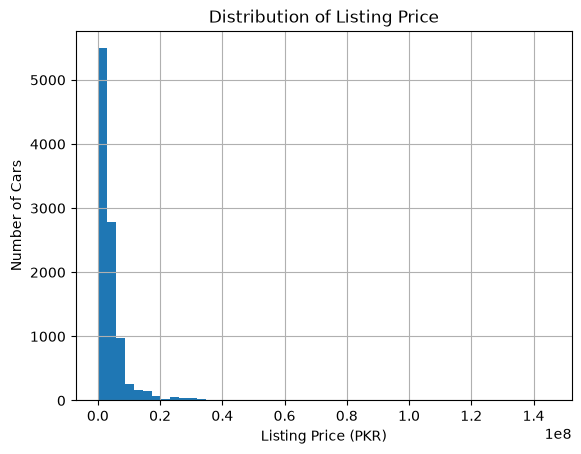

In [19]:
import matplotlib.pyplot as plt

df_final['listingPrice'].hist(bins=50)
plt.xlabel('Listing Price (PKR)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Listing Price')
plt.show()

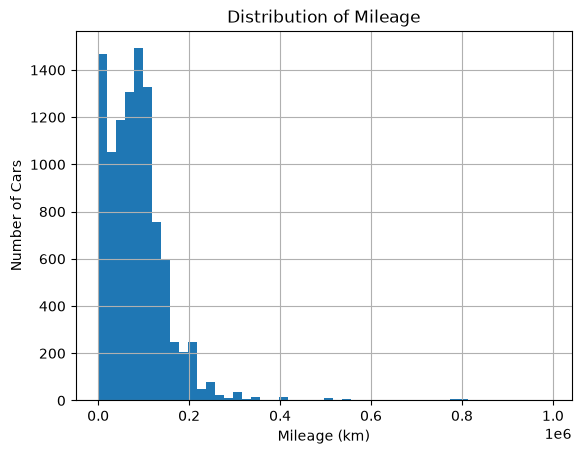

In [20]:
df_final['mileage'].hist(bins=50)
plt.xlabel('Mileage (km)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Mileage')
plt.show()

In [37]:
df_final.sort_values(by='mileage', ascending=False).head(30)

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant
13102,1989.0,Suzuki,Petrol,Suzuki Mehran 1989 for sale in Karachi,Manual,800,1000000,270000.0,Mehran
12552,1991.0,Suzuki,Petrol,Suzuki Khyber 1991 for sale in Karachi,Manual,1000,1000000,400000.0,Khyber
12601,1987.0,Daihatsu,Petrol,Daihatsu Charade 1987 for sale in Karachi,Manual,1000,1000000,750000.0,Charade
8583,1980.0,Mazda,Diesel,Mazda Titan 1980 for sale in Karachi,Manual,3500,1000000,4600000.0,Titan
11608,1982.0,Toyota,Petrol,Toyota Corolla 1982 for sale in Karachi,Manual,1300,1000000,325000.0,Corolla
8248,1996.0,Suzuki,Petrol,Suzuki Khyber 1996 for sale in Karachi,Manual,1000,1000000,350000.0,Khyber
1416,1986.0,Daihatsu,Petrol,Daihatsu Charade 1986 for sale in Karachi,Manual,1000,1000000,600000.0,Charade
2102,1999.0,Suzuki,CNG,Suzuki Khyber 1999 for sale in Karachi,Manual,1000,1000000,475000.0,Khyber
4440,1998.0,Honda,Petrol,Honda City 1998 for sale in Karachi,Manual,1300,1000000,655000.0,City
14012,2004.0,Suzuki,Petrol,Suzuki Baleno 2004 for sale in Karachi,Manual,1300,1000000,950000.0,Baleno


In [21]:
(df_final['mileage'] == 1000000).sum()

np.int64(0)

What this shows: rows sharing mileages of 999999, 999998, 999990, and 999000 are almost certainly the same placeholder problem as the exact 1,000,000 rows, just represented with slightly different rounding. Further down the sorted list, values like 980,000 km on a 2018 Suzuki Swift are not placeholders, they are simply impossible given the car's age. Both problems are fixed back in Stage 2 above (the correct stage for anything that changes `df_final`), not here, this block is only the discovery. See `project/notes/NOTES.md` for the full investigation.

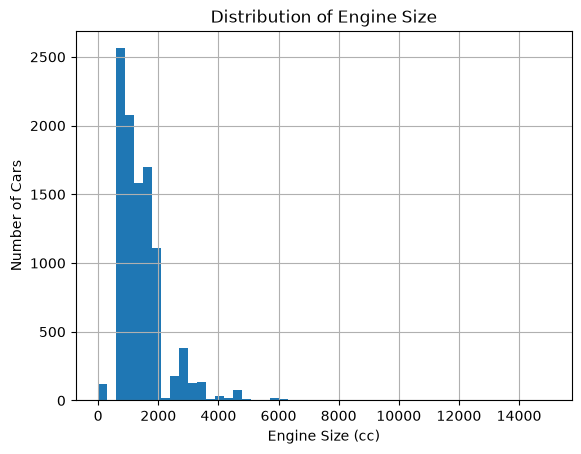

In [22]:
df_final['engine'].hist(bins=50)
plt.xlabel('Engine Size (cc)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Engine Size')
plt.show()

In [23]:
df_final.sort_values(by='engine', ascending=False).head(10)

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant
712,2000.0,Suzuki,Diesel,Suzuki Vitara 2000 for sale in Karachi,Manual,15000,96274,1450000.0,Vitara
8221,1996.0,Honda,Petrol,Honda Civic 1996 for sale in Karachi,Manual,15000,100,1075000.0,Civic
12778,1985.0,Toyota,Diesel,Toyota Land Cruiser 1985 for sale in Karachi,Automatic,15000,98000,6500000.0,Land Cruiser
14680,2006.0,Toyota,Petrol,Toyota IST 2006 for sale in Karachi,Automatic,13004,156000,1550000.0,IST
12319,1995.0,Mitsubishi,Petrol,Mitsubishi Pajero 1995 for sale in Karachi,Automatic,11000,135000,880000.0,Pajero
6586,1995.0,Toyota,LPG,Toyota Crown 1995 for sale in Karachi,Manual,8000,100000,315000.0,Crown
412,2008.0,Suzuki,Petrol,Suzuki Alto 2008 for sale in Karachi,Manual,8000,187000,850000.0,Alto
439,1970.0,Isuzu,Diesel,Isuzu NKR 1970 for sale in Karachi,Manual,6650,120000,4800000.0,NKR
5237,2015.0,Daihatsu,Petrol,Daihatsu Move 2015 for sale in Karachi,Automatic,6600,84962,2350000.0,Move
1294,2012.0,Mercedes Benz,Petrol,Mercedes Benz S Class 2012 for sale in Karachi,Automatic,6203,20000,27500000.0,Benz S Class


In [24]:
(df_final['engine'] > 6000).sum()

np.int64(17)

In [25]:
df_final.sort_values(by='engine', ascending=False).head(17)

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant
712,2000.0,Suzuki,Diesel,Suzuki Vitara 2000 for sale in Karachi,Manual,15000,96274,1450000.0,Vitara
8221,1996.0,Honda,Petrol,Honda Civic 1996 for sale in Karachi,Manual,15000,100,1075000.0,Civic
12778,1985.0,Toyota,Diesel,Toyota Land Cruiser 1985 for sale in Karachi,Automatic,15000,98000,6500000.0,Land Cruiser
14680,2006.0,Toyota,Petrol,Toyota IST 2006 for sale in Karachi,Automatic,13004,156000,1550000.0,IST
12319,1995.0,Mitsubishi,Petrol,Mitsubishi Pajero 1995 for sale in Karachi,Automatic,11000,135000,880000.0,Pajero
6586,1995.0,Toyota,LPG,Toyota Crown 1995 for sale in Karachi,Manual,8000,100000,315000.0,Crown
412,2008.0,Suzuki,Petrol,Suzuki Alto 2008 for sale in Karachi,Manual,8000,187000,850000.0,Alto
439,1970.0,Isuzu,Diesel,Isuzu NKR 1970 for sale in Karachi,Manual,6650,120000,4800000.0,NKR
5237,2015.0,Daihatsu,Petrol,Daihatsu Move 2015 for sale in Karachi,Automatic,6600,84962,2350000.0,Move
1294,2012.0,Mercedes Benz,Petrol,Mercedes Benz S Class 2012 for sale in Karachi,Automatic,6203,20000,27500000.0,Benz S Class


What this shows: the `15000` cluster (Vitara, Civic, Land Cruiser) is a placeholder, the same signature as mileage's problem, an identical, impossible value shared across completely unrelated cars. The Mercedes cluster around 6200-6203cc is the opposite case, a real, consistently repeated spec for a specific high-performance trim, not an error, and was deliberately kept. Everything above 6500cc that wasn't Mercedes is fixed back in Stage 2 above, not here, this block is only the discovery. See `project/notes/NOTES.md` for the full investigation.

Bivariate (feature vs listingPrice)

Multivariate

Stage 4: Feature Engineering

Every change here should trace back to something Stage 3 showed you.

Stage 5: Preprocessing for Modeling

Encoding, scaling, train/test split. Mechanical, not insight-driven. Fit only on train.

Stage 6: Modeling

Baseline first (beat the mean), then multiple linear regression.

Stage 7: Evaluation & Iteration

MAE / RMSE / R² / Adjusted R² on the test set. Residuals. What's next.